# Análise séries temporais de dados Climáticos/Uige

#### A análise de séries temporais de dados climáticos para identificação de ciclos e padrões de longo prazo no Uíge

### Coleta dos Dados Climáticos
EC_Terra3P_HR	Europa	Consórcio EC-Earth, Rossby Center, Instituto Meteorológico e Hidrológico Sueco/SMHI, Norrkoping, Suécia

MPI_ESM1_2_XR	Alemanha, Instituto Max Planck de Meteorologia, Hamburgo 20146, Alemanha
Variáveis: Temperatura máxima,Temperatura minima, umidade max, umidade min.
Período: 14 anos

In [4]:
#### Bibliotecas 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from sklearn.metrics import mean_squared_error
import seaborn as sns 


from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### importação do Dataset

In [5]:
# Load the dataset and ensure proper parsing of columns
clima_df = pd.read_csv('Uige_Clima.csv', sep=';', header=0)

# Convert 'periodo_tempo' to datetime and set it as the index
clima_df['periodo_tempo'] = pd.to_datetime(clima_df['periodo_tempo'], format='%d/%m/%y', errors='coerce')
clima_df.set_index('periodo_tempo', inplace=True)

# Convert 'temperatura_max' and 'temperatura_min' to numeric, handling commas and coercing errors
clima_df['temperatura_max'] = pd.to_numeric(clima_df['temperatura_max'].str.replace(',', '.'), errors='coerce')
clima_df['temperatura_min'] = pd.to_numeric(clima_df['temperatura_min'].str.replace(',', '.'), errors='coerce')

# Display the first few rows of the dataframe
clima_df.head()


,temperatura_max,temperatura_min
periodo_tempo,,
2010-01-01,28.6,19.6
2010-01-02,26.0,19.2
2010-01-03,27.5,18.9
2010-01-04,28.0,18.8
2010-01-05,27.2,18.8


In [6]:

# Exibir as primeiras linhas do dataframe atualizado
clima_df.head()

,temperatura_max,temperatura_min
periodo_tempo,,
2010-01-01,28.6,19.6
2010-01-02,26.0,19.2
2010-01-03,27.5,18.9
2010-01-04,28.0,18.8
2010-01-05,27.2,18.8


In [7]:
# Ver os tipos de dados
clima_df.dtypes


temperatura_max    float64
temperatura_min    float64
dtype: object

In [8]:

#clima_df.index = pd.to_datatime(clima_df.index)
clima_df.index

DatetimeIndex(['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04',
               '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08',
               '2010-01-09', '2010-01-10',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='periodo_tempo', length=5479, freq=None)

#### verificar se há dados nulos

In [9]:
def list_and_visualize_missing_data(dataset):
    # Listing total null items and its percent with respect to all nulls
    total = dataset.isnull().sum().sort_values(ascending=False)
    percent = ((dataset.isnull().sum())/(dataset.isnull().count())).sort_values(ascending=False)
    percent = percent*100
    
    print('Total de dados nulos : \n',total)
    print('% dados nulos : \n',percent)

list_and_visualize_missing_data(clima_df)

Total de dados nulos : 
 temperatura_max    0
temperatura_min    0
dtype: int64
% dados nulos : 
 temperatura_max    0.0
temperatura_min    0.0
dtype: float64


In [10]:
import nbformat
%pip install nbformat>=4.2.0

zsh:1: 4.2.0 not found
Note: you may need to restart the kernel to use updated packages.


In [11]:


import plotly.express as px
# Gráfico dinâmico para todas as variáveis do dataframe clima_df
fig = px.line(clima_df, x=clima_df.index, y=clima_df.columns, title="Tendência e Sazonalidade dos Dados Meteorológicos")
fig.update_layout(xaxis_title="Data", yaxis_title="Valores", legend_title="Variáveis")
fig.show()

# Gráfico dinâmico para o período de 2023 a 2024
clima_df_filtered = clima_df['2023':'2024']
fig_filtered = px.line(clima_df_filtered, x=clima_df_filtered.index, y=clima_df_filtered.columns, title="Visão Detalhada (2023-2024)")
fig_filtered.update_layout(xaxis_title="Data", yaxis_title="Valores", legend_title="Variáveis")
fig_filtered.show()

In [12]:
#Dividir o conjunto de dados em dados de treinamento e teste
train_df = clima_df['2010':'2021'].resample('ME').mean()
train_df = train_df.fillna(train_df.mean())
test_df = clima_df['2022':'2024'].resample('ME').mean()
test_df = test_df.fillna(test_df.mean())


In [13]:
train_df.head()

,temperatura_max,temperatura_min
periodo_tempo,,
2010-01-31,27.696774,19.041935
2010-02-28,28.021429,19.010714
2010-03-31,28.532258,19.525806
2010-04-30,27.453333,19.080000
2010-05-31,28.232258,18.106452


In [14]:
# visualizar as últimas linhas do arquivo
train_df.tail()

,temperatura_max,temperatura_min
periodo_tempo,,
2021-08-31,32.187097,17.290323
2021-09-30,31.356667,18.750000
2021-10-31,29.754839,18.909677
2021-11-30,27.293333,18.553333
2021-12-31,26.406452,18.670968


In [15]:
#Visualizar os dados de treinamento
test_df.head()

,temperatura_max,temperatura_min
periodo_tempo,,
2022-01-31,26.422581,17.738710
2022-02-28,27.467857,17.875000
2022-03-31,27.422581,18.706452
2022-04-30,27.073333,18.746667
2022-05-31,29.883871,17.880645


In [16]:
#Visualizar últimos dados de treinamento
test_df.tail()

,temperatura_max,temperatura_min
periodo_tempo,,
2024-08-31,27.241935,17.203226
2024-09-30,28.306667,19.233333
2024-10-31,28.716129,20.596774
2024-11-30,27.603333,20.930000
2024-12-31,28.651613,20.874194


In [17]:
#Visualizar os dados de teste
train_df.describe()

,temperatura_max,temperatura_min
count,144.000000,144.000000
mean,28.802717,17.729906
std,1.242422,1.462150
min,25.635714,14.109677
25%,27.940323,17.115000
50%,28.770376,18.382759
75%,29.564355,18.733871
max,33.851613,19.664516


In [18]:
#Visualizar os dados de teste
test_df.describe()

,temperatura_max,temperatura_min
count,36.000000,36.000000
mean,29.062035,19.100943
std,1.666140,1.811762
min,26.422581,14.522581
25%,27.726290,17.957661
50%,28.858065,19.036022
75%,29.929570,20.651613
max,33.122581,21.387097


In [19]:
# verificar a média de rolamento e o desvio padrão de rolamento
def plot_rolling_mean_std(ts):
    rolling_mean = ts.rolling(12).mean()
    rolling_std = ts.rolling(12).std()
    plt.figure(figsize=(22,10))

    plt.plot(ts, label='Média Atual')
    plt.plot(rolling_mean, label='Média Móvel')
    plt.plot(rolling_std, label = 'Std contínuo')
    plt.xlabel("Data")
    plt.ylabel("Temperatura")
    plt.title('Média Móvel & Desvio Padrão Contínuo')
    plt.legend()
    plt.show()


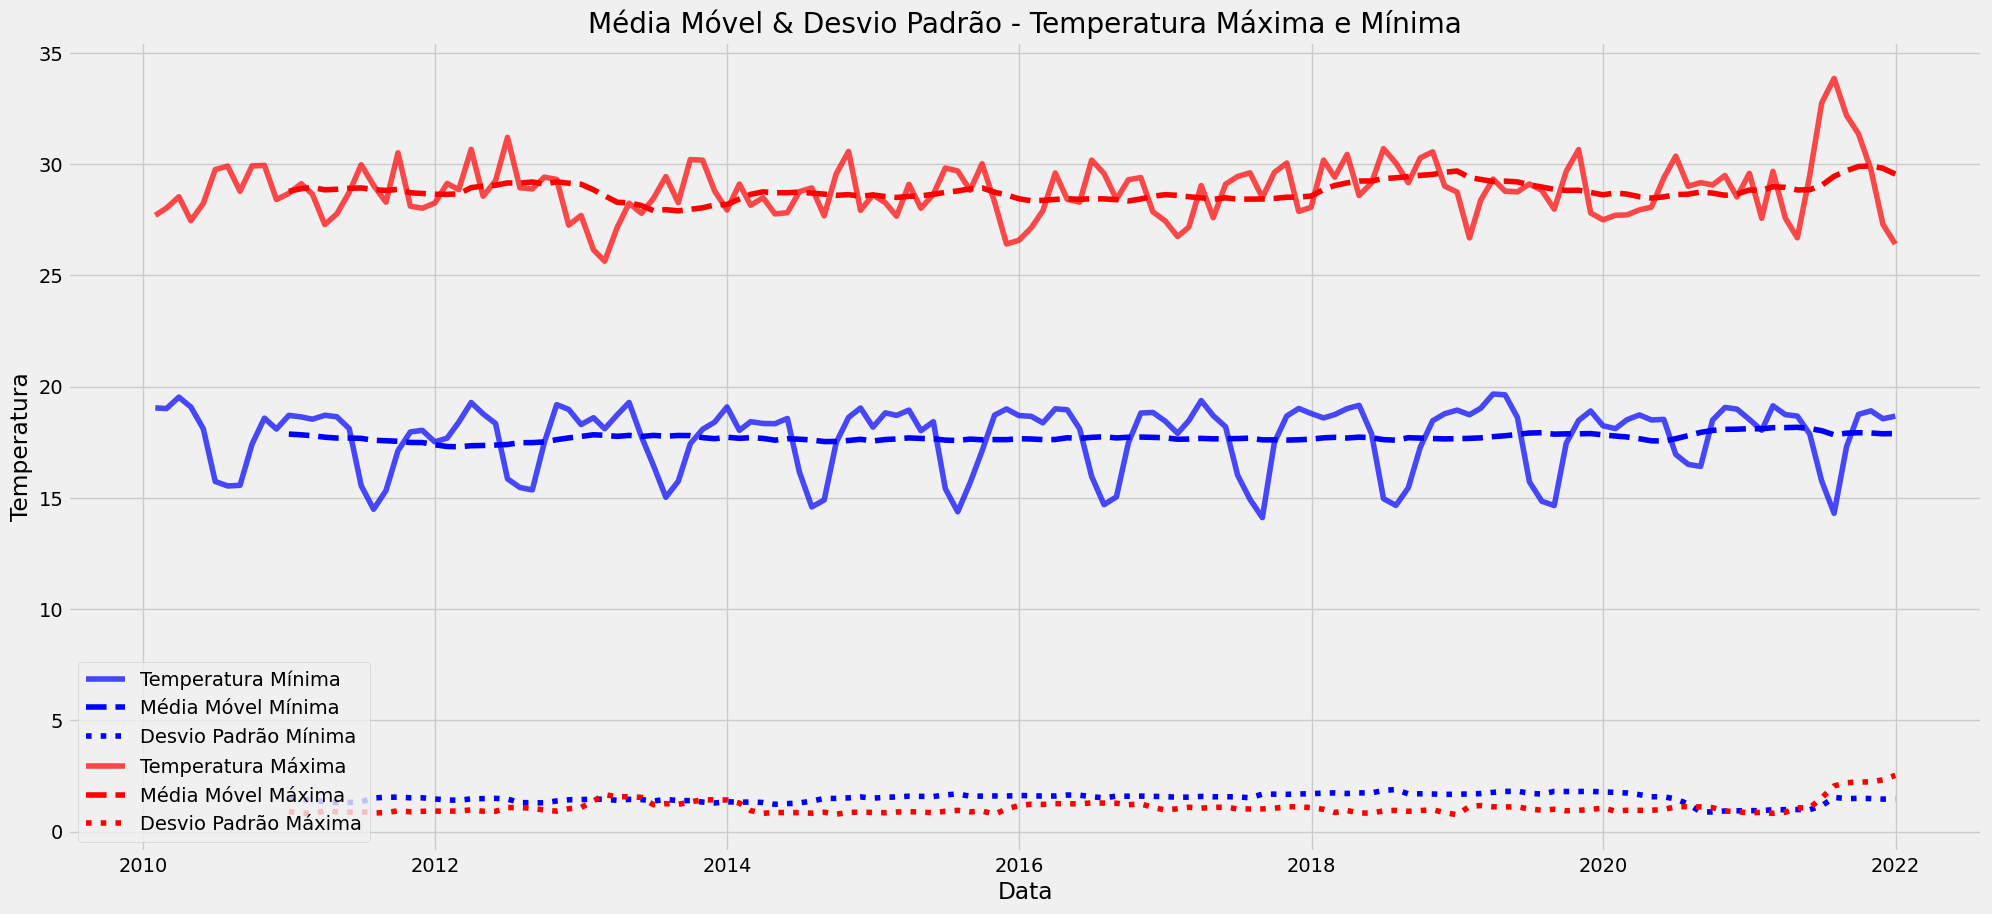

In [20]:
plt.figure(figsize=(22, 10))

# Temperatura mínima
plt.plot(train_df.index, train_df['temperatura_min'], label='Temperatura Mínima', color='blue', alpha=0.7)
plt.plot(train_df.index, train_df['temperatura_min'].rolling(12).mean(), label='Média Móvel Mínima', color='blue', linestyle='--')
plt.plot(train_df.index, train_df['temperatura_min'].rolling(12).std(), label='Desvio Padrão Mínima', color='blue', linestyle=':')

# Temperatura máxima
plt.plot(train_df.index, train_df['temperatura_max'], label='Temperatura Máxima', color='red', alpha=0.7)
plt.plot(train_df.index, train_df['temperatura_max'].rolling(12).mean(), label='Média Móvel Máxima', color='red', linestyle='--')
plt.plot(train_df.index, train_df['temperatura_max'].rolling(12).std(), label='Desvio Padrão Máxima', color='red', linestyle=':')

plt.xlabel("Data")
plt.ylabel("Temperatura")
plt.title('Média Móvel & Desvio Padrão - Temperatura Máxima e Mínima')
plt.legend()
plt.show()


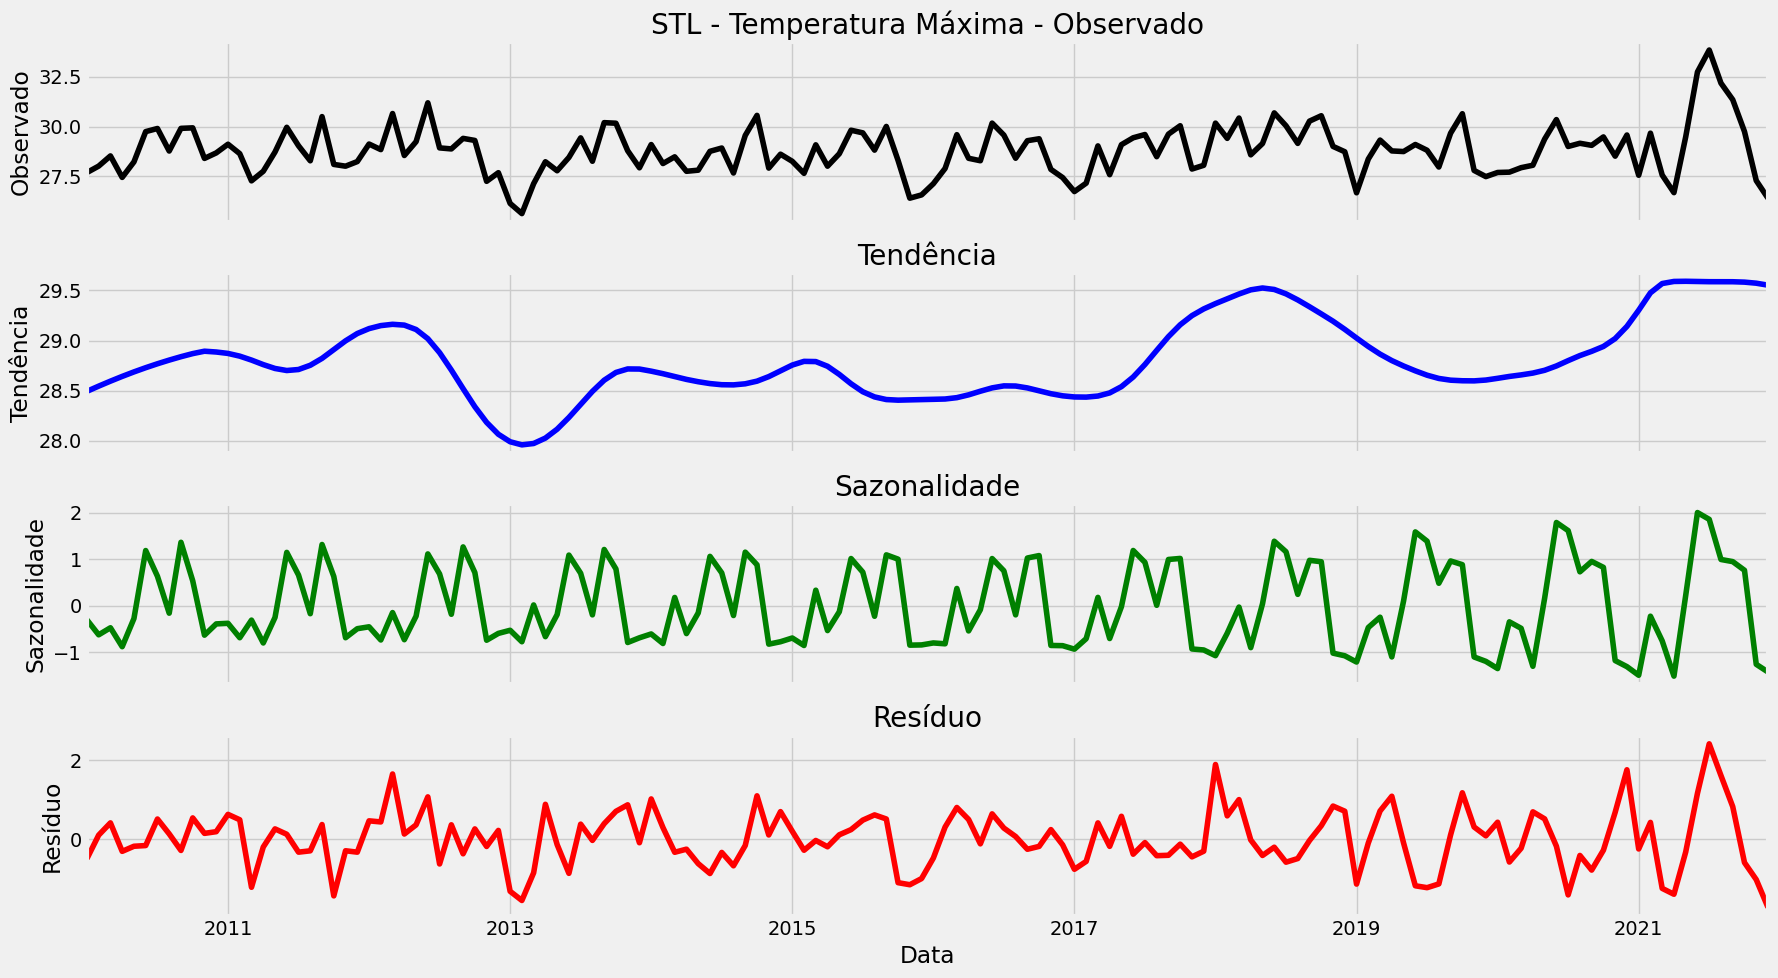

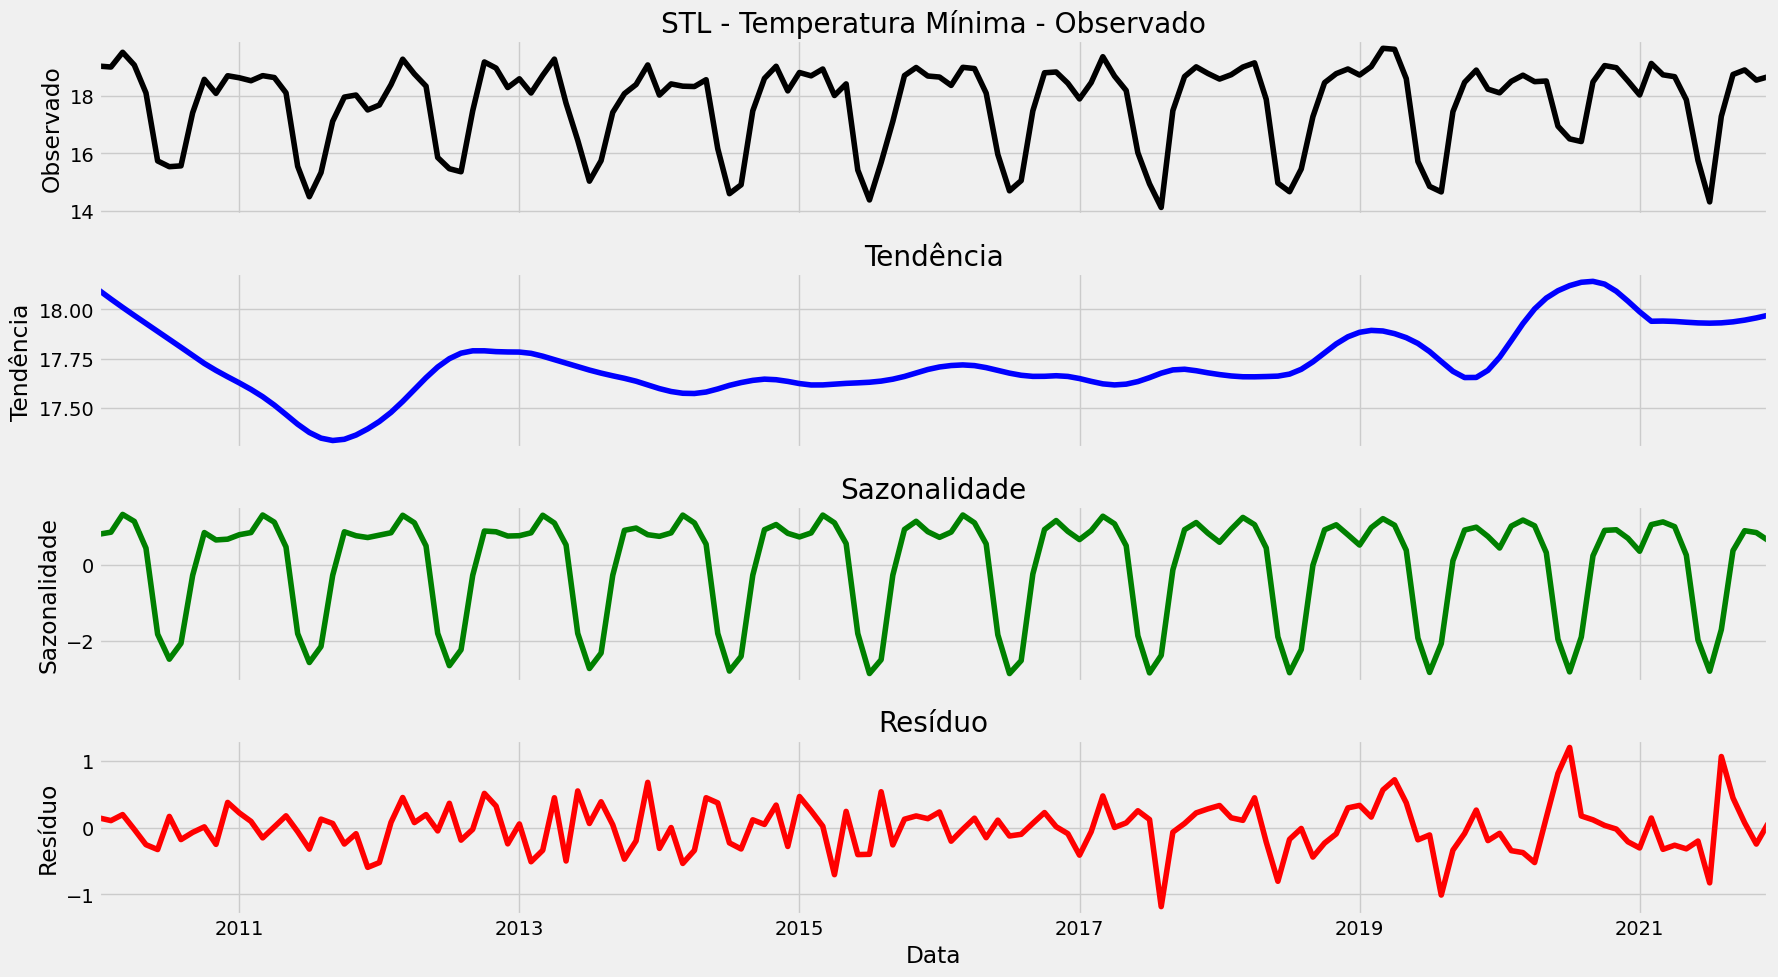

In [21]:
from statsmodels.tsa.seasonal import STL

def plot_stl_result(stl_result, title):
    fig, axes = plt.subplots(4, 1, figsize=(18, 10), sharex=True)
    stl_result.observed.plot(ax=axes[0], color='black')
    axes[0].set_ylabel('Observado')
    axes[0].set_title(f'{title} - Observado')
    stl_result.trend.plot(ax=axes[1], color='blue')
    axes[1].set_ylabel('Tendência')
    axes[1].set_title('Tendência')
    stl_result.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_ylabel('Sazonalidade')
    axes[2].set_title('Sazonalidade')
    stl_result.resid.plot(ax=axes[3], color='red')
    axes[3].set_ylabel('Resíduo')
    axes[3].set_title('Resíduo')
    plt.xlabel('Data')
    plt.tight_layout()
    plt.show()

# STL para temperatura_max
stl_max = STL(train_df['temperatura_max'], seasonal=13)
stl_result_max = stl_max.fit()
plot_stl_result(stl_result_max, 'STL - Temperatura Máxima')

# STL para temperatura_min
stl_min = STL(train_df['temperatura_min'], seasonal=13)
stl_result_min = stl_min.fit()
plot_stl_result(stl_result_min, 'STL - Temperatura Mínima')

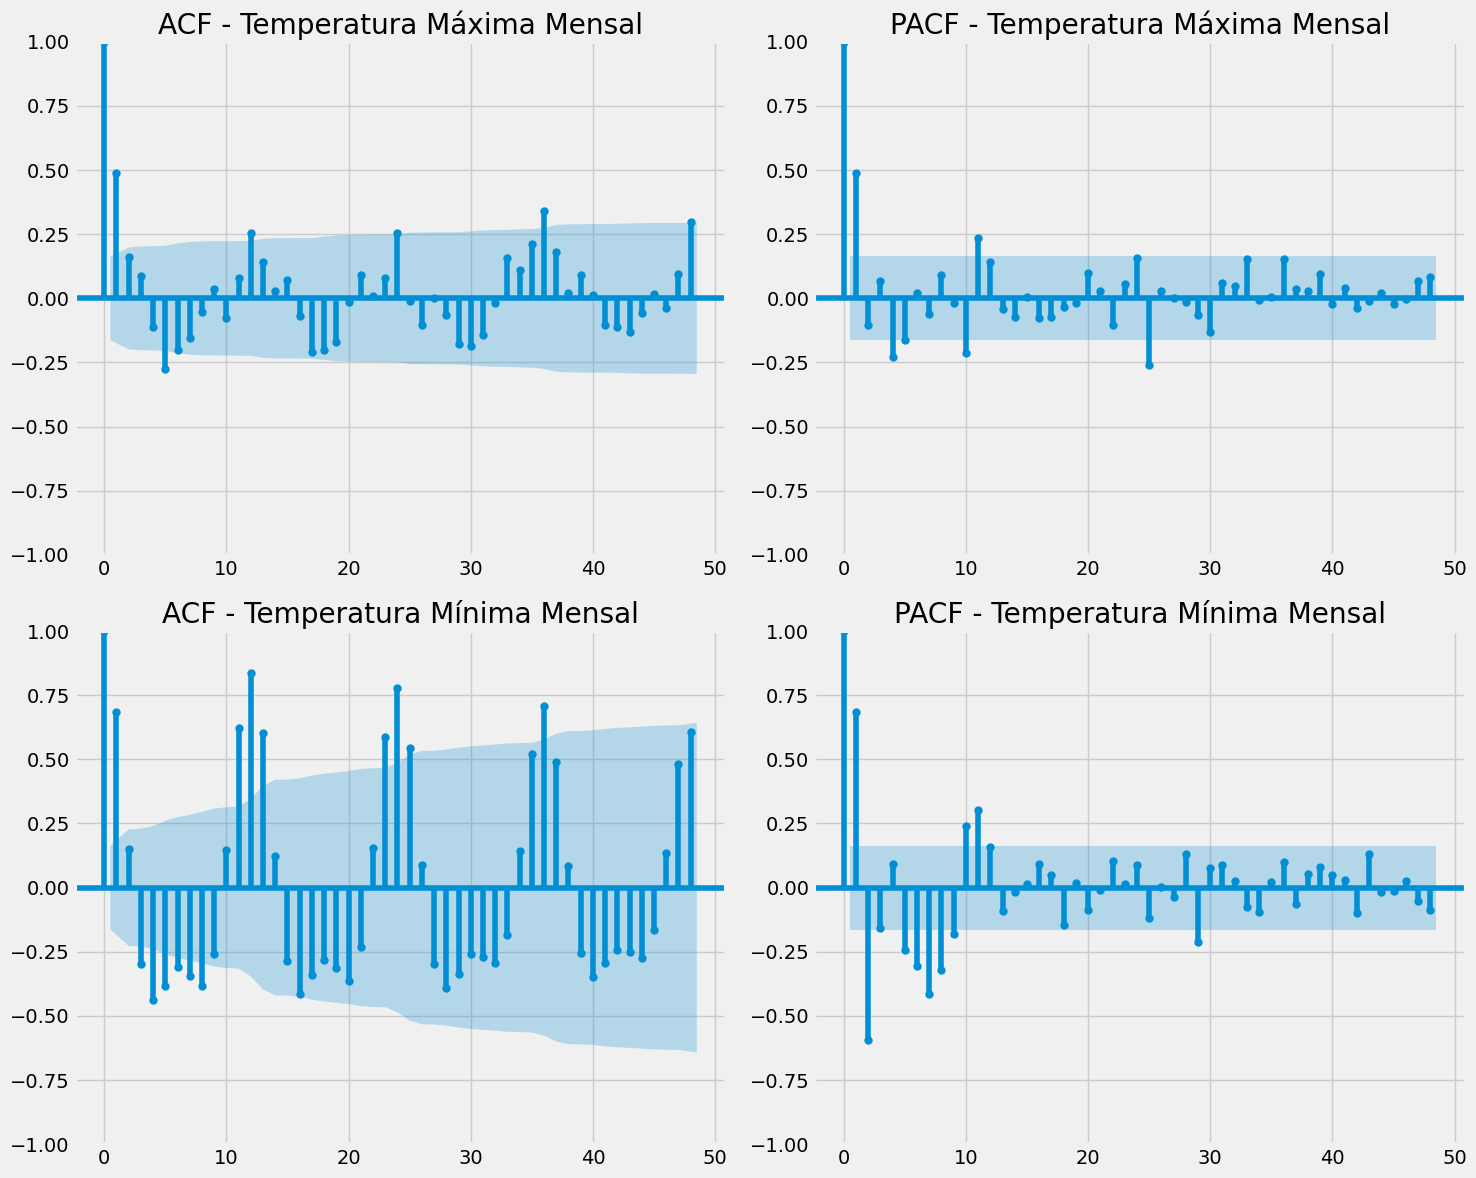

In [22]:
# Gerar os gráficos de ACF e PACF para a temperatura média, máxima e mínima mensal
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ACF e PACF para temperatura máxima
plot_acf(train_df["temperatura_max"], lags=48, ax=axes[0, 0])
axes[0, 0].set_title("ACF - Temperatura Máxima Mensal")
plot_pacf(train_df["temperatura_max"], lags=48, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF - Temperatura Máxima Mensal")

# ACF e PACF para temperatura mínima
plot_acf(train_df["temperatura_min"], lags=48, ax=axes[1, 0])
axes[1, 0].set_title("ACF - Temperatura Mínima Mensal")
plot_pacf(train_df["temperatura_min"], lags=48, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF - Temperatura Mínima Mensal")

# Ajustar layout
plt.tight_layout()
plt.show()


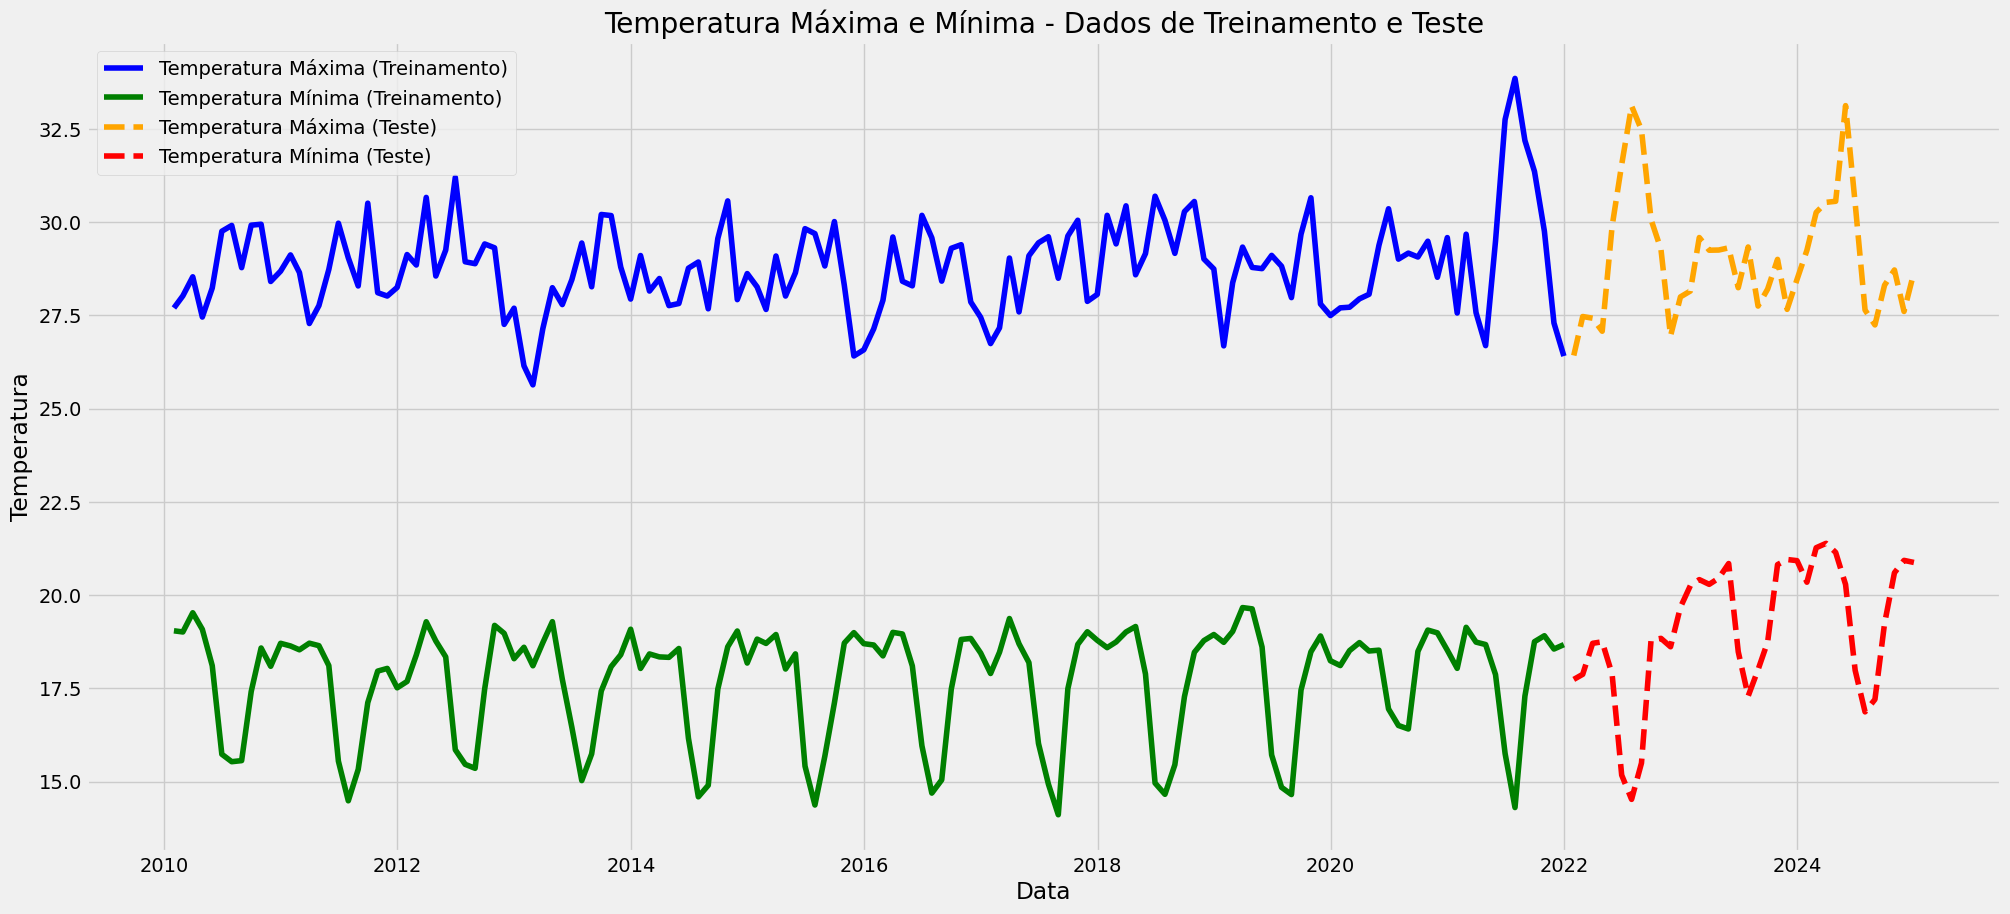

In [23]:
# Plotar temperaturas máxima e mínima do conjunto de treinamento e teste no mesmo gráfico
plt.figure(figsize=(22, 10))

# Dados de treinamento
plt.plot(train_df.index, train_df.temperatura_max, label='Temperatura Máxima (Treinamento)', color='blue')
plt.plot(train_df.index, train_df.temperatura_min, label='Temperatura Mínima (Treinamento)', color='green')

# Dados de teste
plt.plot(test_df.index, test_df.temperatura_max, label='Temperatura Máxima (Teste)', color='orange', linestyle='--')
plt.plot(test_df.index, test_df.temperatura_min, label='Temperatura Mínima (Teste)', color='red', linestyle='--')

# Configurações do gráfico
plt.xlabel("Data")
plt.ylabel("Temperatura")
plt.title("Temperatura Máxima e Mínima - Dados de Treinamento e Teste")
plt.legend()
plt.show()

In [24]:
import plotly.express as px

# Gerar dados trimestrais para treino e teste
train_quarterly = train_df.resample('Q').mean()
train_quarterly['quarter'] = train_quarterly.index.to_period('Q')
test_quarterly = test_df.resample('Q').mean()
test_quarterly['quarter'] = test_quarterly.index.to_period('Q')

# Concatenar os dados trimestrais de treino e teste, adicionando uma coluna de origem
train_quarterly_plot = train_quarterly.copy()
train_quarterly_plot['Tipo'] = 'Treinamento'
test_quarterly_plot = test_quarterly.copy()
test_quarterly_plot['Tipo'] = 'Teste'

quarterly_all = pd.concat([train_quarterly_plot, test_quarterly_plot])
quarterly_all = quarterly_all.reset_index(drop=True)

# Converter a coluna 'quarter' para string para evitar erro de serialização
quarterly_all['quarter'] = quarterly_all['quarter'].astype(str)

# Gráfico dinâmico
fig = px.line(
    quarterly_all,
    x='quarter',
    y=['temperatura_max', 'temperatura_min'],
    color='Tipo',
    labels={'value': 'Temperatura', 'quarter': 'Trimestre', 'variable': 'Variável'},
    title='Temperatura Máxima e Mínima - Dados Trimestrais'
)
fig.update_layout(xaxis_tickangle=45)
fig.show()


/var/folders/km/m1h59rm119n9h_rcz_wg84nc0000gn/T/ipykernel_7471/3614410317.py:4: FutureWarning:

'Q' is deprecated and will be removed in a future version, please use 'QE' instead.

/var/folders/km/m1h59rm119n9h_rcz_wg84nc0000gn/T/ipykernel_7471/3614410317.py:6: FutureWarning:

'Q' is deprecated and will be removed in a future version, please use 'QE' instead.



# ===== Previsão de Temperatura Máxima =====

In [25]:
def fit_prophet(train_df):
    # Rename columns to match Prophet's requirements
    train_df_renamed = train_df.reset_index().rename(columns={'periodo_tempo': 'ds', 'temperatura_max': 'y'})
    
    # Initialize the Prophet model
    m = Prophet()
    
    # Fit the model
    m.fit(train_df_renamed)
    
    return m

# Fit the Prophet model using the training data
m = fit_prophet(train_df)

21:38:30 - cmdstanpy - INFO - Chain [1] start processing
21:38:30 - cmdstanpy - INFO - Chain [1] done processing


21:38:30 - cmdstanpy - INFO - Chain [1] start processing
21:38:30 - cmdstanpy - INFO - Chain [1] done processing


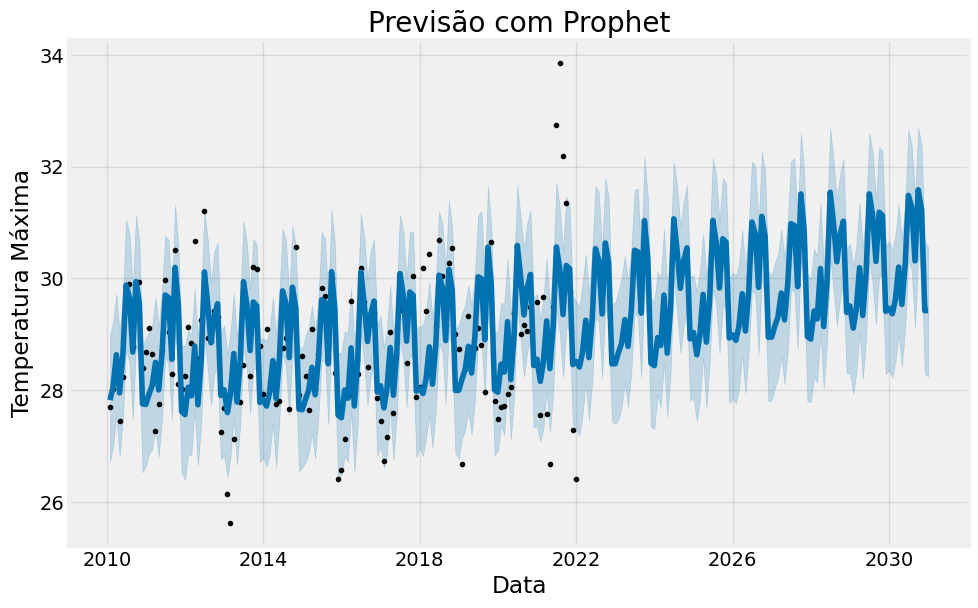

In [26]:
# Preparar os dados para o Prophet
df_prophet = train_df.reset_index()
df_prophet.rename(columns={'periodo_tempo': 'ds', 'temperatura_max': 'y'}, inplace=True)

# Criar e ajustar o modelo Prophet
modelo_prophet_max = Prophet()
modelo_prophet_max.fit(df_prophet)

# Criar um dataframe para as datas futuras
future_dates = modelo_prophet_max.make_future_dataframe(periods=108, freq='ME')

# Fazer a previsão
forecast_prophet = modelo_prophet_max.predict(future_dates)

# Visualizar a previsão
fig = modelo_prophet_max.plot(forecast_prophet)
plt.title('Previsão com Prophet')
plt.xlabel('Data')
plt.ylabel('Temperatura Máxima')
plt.show()


## Previsão futura

In [27]:
import plotly.graph_objects as go

# Gerar datas futuras para 2025-2030
future_max = modelo_prophet_max.make_future_dataframe(periods=120, freq='ME')  # 66 meses de 2025-01 a 2030-06

# Fazer a previsão
previsao = modelo_prophet_max.predict(future_max)
previsao = previsao[(previsao['ds'] >= '2024-12-31') & (previsao['ds'] <= '2030-12-31')]

# Concatenar dados históricos de temperatura mínima
historico = pd.concat([
    train_df.reset_index()[['periodo_tempo', 'temperatura_max']].rename(columns={'periodo_tempo': 'ds', 'temperatura_max': 'yhat'}),
    test_df.reset_index()[['periodo_tempo', 'temperatura_max']].rename(columns={'periodo_tempo': 'ds', 'temperatura_max': 'yhat'})
])

# Ajustar previsão para continuidade visual
ultimo_valor_historico = historico['yhat'].iloc[-1]
primeiro_valor_previsao = previsao['yhat'].iloc[0]
ajuste = ultimo_valor_historico - primeiro_valor_previsao
previsao_ajustada = previsao.copy()
previsao_ajustada['yhat'] = previsao_ajustada['yhat'] + ajuste

# Plotar
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=historico['ds'], y=historico['yhat'],
    mode='lines', name='Histórico', line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=previsao_ajustada['ds'], y=previsao_ajustada['yhat'],
    mode='lines', name='Previsão (2025-2030)', line=dict(color='orange')
))
fig.update_layout(
    title='Previsão da Temperatura Máxima (2025-2030)',
    xaxis_title='Data',
    yaxis_title='Temperatura Max',
    legend_title='Período'
)
fig.show()


# ==Previsão da Temperatura Mínima ==

10:38:33 - cmdstanpy - INFO - Chain [1] start processing
10:38:33 - cmdstanpy - INFO - Chain [1] done processing


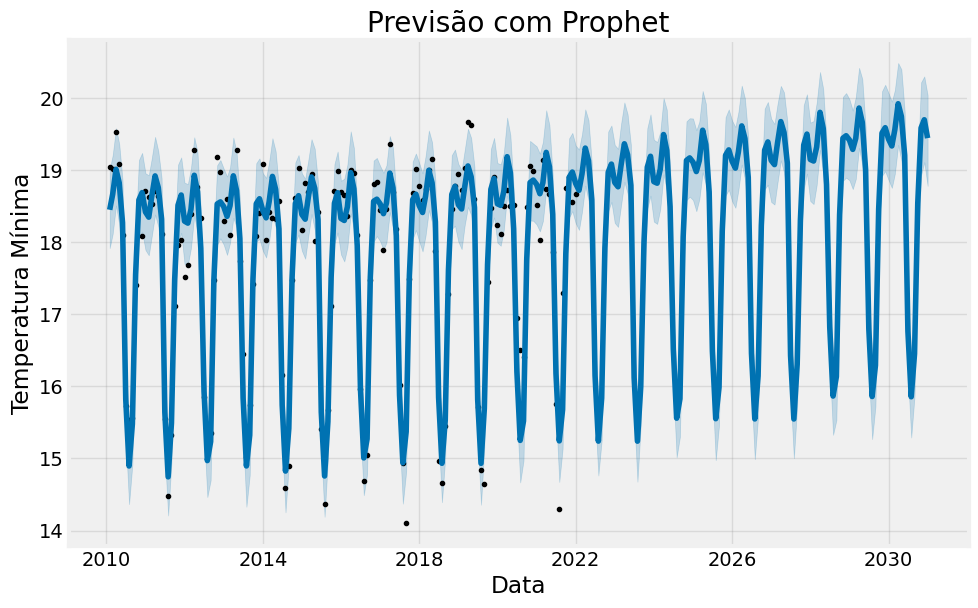

In [55]:
# Preparar os dados para o Prophet
df_prophet = train_df.reset_index()
df_prophet.rename(columns={'periodo_tempo': 'ds', 'temperatura_min': 'y'}, inplace=True)

# Criar e ajustar o modelo Prophet
modelo_prophet_min = Prophet()
modelo_prophet_min.fit(df_prophet)

# Criar um dataframe para as datas futuras
future_dates = modelo_prophet_min.make_future_dataframe(periods=108, freq='ME')

# Fazer a previsão
forecast_prophet = modelo_prophet_min.predict(future_dates)

# Visualizar a previsão
fig = modelo_prophet_min.plot(forecast_prophet)
plt.title('Previsão com Prophet')
plt.xlabel('Data')
plt.ylabel('Temperatura Mínima')
plt.show()


In [56]:
def fit_prophet(train_df):
    # Rename columns to match Prophet's requirements
    train_df_renamed = train_df.reset_index().rename(columns={'periodo_tempo': 'ds', 'temperatura_min': 'y'})
    
    # Initialize the Prophet model
    modelo_prophet_min = Prophet()
    
    # Fit the model
    modelo_prophet_min.fit(train_df_renamed)
    
    return modelo_prophet_min

# Fit the Prophet model using the training data
modelo_prophet_min = fit_prophet(train_df)

10:38:34 - cmdstanpy - INFO - Chain [1] start processing
10:38:34 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
import plotly.graph_objects as go

# Gerar datas futuras para 2025-2030
future_min = modelo_prophet_min.make_future_dataframe(periods=120, freq='ME')  # 66 meses de 2025-01 a 2030-06

# Fazer a previsão
previsao = modelo_prophet_min.predict(future_min)
previsao = previsao[(previsao['ds'] >= '2024-12-31') & (previsao['ds'] <= '2030-12-31')]

# Concatenar dados históricos de temperatura mínima
historico = pd.concat([
    train_df.reset_index()[['periodo_tempo', 'temperatura_min']].rename(columns={'periodo_tempo': 'ds', 'temperatura_min': 'yhat'}),
    test_df.reset_index()[['periodo_tempo', 'temperatura_min']].rename(columns={'periodo_tempo': 'ds', 'temperatura_min': 'yhat'})
])

# Ajustar previsão para continuidade visual
ultimo_valor_historico = historico['yhat'].iloc[-1]
primeiro_valor_previsao = previsao['yhat'].iloc[0]
ajuste = ultimo_valor_historico - primeiro_valor_previsao
previsao_ajustada = previsao.copy()
previsao_ajustada['yhat'] = previsao_ajustada['yhat'] + ajuste

# Plotar
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=historico['ds'], y=historico['yhat'],
    mode='lines', name='Histórico', line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=previsao_ajustada['ds'], y=previsao_ajustada['yhat'],
    mode='lines', name='Previsão (2025-2030)', line=dict(color='orange')
))
fig.update_layout(
    title='Previsão da Temperatura Mínima (2025-2030)',
    xaxis_title='Data',
    yaxis_title='Temperatura Mínima',
    legend_title='Período'
)
fig.show()


## Avaliação e resumo do modelo


In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Criar e ajustar o modelo Prophet para temperatura máxima
df_prophet_max = train_df.reset_index().rename(columns={'periodo_tempo': 'ds', 'temperatura_max': 'y'})
modelo_prophet_max = Prophet()
modelo_prophet_max.fit(df_prophet_max)

# Fazer a previsão para temperatura máxima
future_dates_max = modelo_prophet_max.make_future_dataframe(periods=len(test_df), freq='ME')
forecast_prophet_max = modelo_prophet_max.predict(future_dates_max)

# Criar e ajustar o modelo Prophet para temperatura mínima
df_prophet_min = train_df.reset_index().rename(columns={'periodo_tempo': 'ds', 'temperatura_min': 'y'})
modelo_prophet_min = Prophet()
modelo_prophet_min.fit(df_prophet_min)

# Fazer a previsão para temperatura mínima
future_dates_min = modelo_prophet_min.make_future_dataframe(periods=len(test_df), freq='ME')
forecast_prophet_min = modelo_prophet_min.predict(future_dates_min)

# Reindexar as previsões do Prophet para corresponder ao índice do conjunto de teste
forecast_test_max = forecast_prophet_max.set_index('ds').reindex(test_df.index)
forecast_test_min = forecast_prophet_min.set_index('ds').reindex(test_df.index)

# Remover linhas com valores NaN
valid_max = ~forecast_test_max['yhat'].isna() & ~test_df['temperatura_max'].isna()
valid_min = ~forecast_test_min['yhat'].isna() & ~test_df['temperatura_min'].isna()

# Calcular as métricas de erro para temperatura_max
mae_max = mean_absolute_error(test_df['temperatura_max'][valid_max], forecast_test_max['yhat'][valid_max])
mse_max = mean_squared_error(test_df['temperatura_max'][valid_max], forecast_test_max['yhat'][valid_max])
rmse_max = np.sqrt(mse_max)

# Calcular as métricas de erro para temperatura_min
mae_min = mean_absolute_error(test_df['temperatura_min'][valid_min], forecast_test_min['yhat'][valid_min])
mse_min = mean_squared_error(test_df['temperatura_min'][valid_min], forecast_test_min['yhat'][valid_min])
rmse_min = np.sqrt(mse_min)

# Exibir o resumo da qualidade do modelo
print("Resumo da Qualidade do Modelo Prophet:")
print("Temperatura Máxima:")
print(f"Mean Absolute Error (MAE): {mae_max:.2f}")
print(f"Mean Squared Error (MSE): {mse_max:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_max:.2f}")
print("\nTemperatura Mínima:")
print(f"Mean Absolute Error (MAE): {mae_min:.2f}")
print(f"Mean Squared Error (MSE): {mse_min:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_min:.2f}")

10:38:34 - cmdstanpy - INFO - Chain [1] start processing
10:38:34 - cmdstanpy - INFO - Chain [1] done processing
10:38:34 - cmdstanpy - INFO - Chain [1] start processing
10:38:34 - cmdstanpy - INFO - Chain [1] done processing


Resumo da Qualidade do Modelo Prophet:
Temperatura Máxima:
Mean Absolute Error (MAE): 1.37
Mean Squared Error (MSE): 2.74
Root Mean Squared Error (RMSE): 1.66

Temperatura Mínima:
Mean Absolute Error (MAE): 1.32
Mean Squared Error (MSE): 2.08
Root Mean Squared Error (RMSE): 1.44


O modelo utilizado é adequado para as séries de temperatura máxima e mínima, considerando:

Indica boa precisão, com erros médios em torno de 1.4 °C.

Boa proximidade entre MAE e RMSE (indicando poucos outliers)

Simplicidade do Prophet e sua capacidade de lidar com tendências e sazonalidade.

## Salvar dados da previsão

In [59]:
# Gerar datas futuras para 2025-2030
future_max = modelo_prophet_max.make_future_dataframe(periods=120, freq='ME')  # 66 meses de 2025-01 a 2030-06

# Fazer a previsão
previsao2 = modelo_prophet_max.predict(future_max)
previsao2 = previsao2[(previsao2['ds'] >= '2025-01-01') & (previsao['ds'] <= '2030-12-31')]


# Gerar datas futuras para 2025-2030
future_min = modelo_prophet_min.make_future_dataframe(periods=120, freq='ME')  # 66 meses de 2025-01 a 2030-06

# Fazer a previsão
previsao = modelo_prophet_min.predict(future_min)
previsao = previsao[(previsao['ds'] >= '2025-01-01') & (previsao['ds'] <= '2030-12-31')]


# Unir as previsões em um único DataFrame
previsao_unida = pd.DataFrame({
	'periodo_tempo': previsao2['ds'],
	'temperatura_max': previsao2['yhat'],
	'temperatura_min': previsao['yhat']
})

# Salvar apenas o período de 2025 a 2030
previsao_unida = previsao_unida[(previsao_unida['periodo_tempo'] >= '2025-01-01') & (previsao_unida['periodo_tempo'] <= '2030-12-31')]

previsao_unida.to_csv('previsao_temperatura_2025_2030.csv', index=False)

# Previsao em Trimestre MINIMA


In [33]:
# Agrupar a previsão ajustada por trimestre e calcular a média
previsao_ajustada['quarter'] = previsao_ajustada['ds'].dt.to_period('Q')
previsao_trimestral = previsao_ajustada.groupby('quarter')['yhat'].mean().reset_index()

# Visualizar os primeiros trimestres
previsao_trimestral.head()


,quarter,yhat
0,2024Q4,20.874194
1,2025Q1,20.986773
2,2025Q2,19.942928
3,2025Q3,18.325996
4,2025Q4,20.967921


In [34]:
import plotly.express as px

# Converter a coluna 'quarter' para string para evitar erro de serialização
previsao_trimestral_plot = previsao_trimestral.copy()
previsao_trimestral_plot['quarter'] = previsao_trimestral_plot['quarter'].astype(str)

# Gráfico dinâmico da previsão trimestral da temperatura mínima (2025-2030)
fig = px.line(
    previsao_trimestral_plot,
    x='quarter',
    y='yhat',
    title='Previsão Trimestral da Temperatura Mínima (2025-2030)',
    labels={'quarter': 'Trimestre', 'yhat': 'Temperatura Mínima (°C)'},
    markers=True
)
fig.update_layout(
    xaxis_tickangle=45,
    xaxis=dict(tickmode='linear'),
    yaxis=dict(tickformat=".1f"),
    width=900,
    height=500,
    font=dict(size=16),
    plot_bgcolor='white',
    margin=dict(l=60, r=30, t=60, b=60)
)
fig.update_traces(line=dict(width=3), marker=dict(size=8, color='orange'))
fig.show()

# Previsao trimestral da temperatura maxima

In [35]:
import plotly.graph_objects as go

# Gerar datas futuras para 2025-2030
future_max_tr = modelo_prophet_max.make_future_dataframe(periods=102, freq='Q')  # 66 meses de 2025-01 a 2030-06

# Fazer a previsão
previsao = modelo_prophet_max.predict(future_max_tr)
previsao = previsao[(previsao['ds'] >= '2025-01-01') & (previsao['ds'] <= '2030-12-31')]



# Plotar
fig = go.Figure()
fig.add_trace(go.Scatter(
         x=previsao['ds'], y=previsao['yhat'],
        mode='lines', name='Previsão (2025-2030)', line=dict(color='orange')
))
fig.update_layout(
    title='Previsão da Temperatura Máxima (2025-2030)',
    xaxis_title='Data',
    yaxis_title='Temperatura Máxima',
    legend_title='Período'
)
fig.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/prophet/forecaster.py:1854: FutureWarning:

'Q' is deprecated and will be removed in a future version, please use 'QE' instead.



## Previsão por trimestre

In [36]:
import plotly.express as px

# Gerar datas futuras para 5 anos (2025-2030)
future_5_years = modelo_prophet_max.make_future_dataframe(periods=108, freq='ME')  # 6 anos, mas vamos filtrar 2025-2030

# Fazer a previsão
forecast_5_years = modelo_prophet_max.predict(future_5_years)

# Filtrar apenas o período de previsão (2025-2030)
# Filtrar apenas o período de previsão (2025-2030)
forecast_5_years_filtered = forecast_5_years[(forecast_5_years['ds'] >= '2025-01-01') & (forecast_5_years['ds'] <= '2030-12-31')]

# Adicionar coluna de trimestre
forecast_5_years_filtered['quarter'] = forecast_5_years_filtered['ds'].dt.to_period('Q')

# Agrupar por trimestre e calcular a média da previsão
forecast_5_years_quarterly = forecast_5_years_filtered.groupby('quarter')['yhat'].mean().reset_index()

# Converter a coluna 'quarter' para string para evitar erro de serialização
forecast_5_years_quarterly['quarter'] = forecast_5_years_quarterly['quarter'].astype(str)

# Gráfico dinâmico da previsão
fig_5y = px.line(
    forecast_5_years_quarterly,
    x='quarter',
    y='yhat',
    title='Previsão com Prophet - Temperatura Máxima (2025-2030)',
    labels={'quarter': 'Trimestre', 'yhat': 'Temperatura Máxima'}
)
fig_5y.show()


/var/folders/km/m1h59rm119n9h_rcz_wg84nc0000gn/T/ipykernel_7471/2780979488.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Previsão do Mês atual

Sabendo que a partir deo mês de maio começa o tempo seco em Angola, procuramos saber como será o comportamento do clima
para esta época na cidade do Uíge

In [62]:
import numpy as np

# Gerar datas diárias para maio de 2025
maio_2025_diario = pd.date_range(start='2025-05-01', end='2025-07-30', freq='D')
df_maio_2025_diario = pd.DataFrame({'ds': maio_2025_diario})

# Prever temperaturas máximas e mínimas diárias
forecast_max_diario = modelo_prophet_max.predict(df_maio_2025_diario)
forecast_min_diario = modelo_prophet_min.predict(df_maio_2025_diario)

# Gráfico diário
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=forecast_max_diario['ds'], y=forecast_max_diario['yhat'],
    mode='lines+markers', name='Temp. Máxima (Diária)', line=dict(color='red')
))
fig.add_trace(go.Scatter(
    x=forecast_min_diario['ds'], y=forecast_min_diario['yhat'],
    mode='lines+markers', name='Temp. Mínima (Diária)', line=dict(color='blue')
))
fig.update_layout(
    title='Previsão Diária de Temperatura Máxima e Mínima - Maio - Junho 2025',
    xaxis_title='Data',
    yaxis_title='Temperatura (°C)',
    legend_title='Legenda'
)
fig.show()

# Gerar datas semanais para maio de 2025 (toda segunda-feira)
maio_2025_semanal = pd.date_range(start='2025-05-01', end='2025-07-30', freq='W-MON')
df_maio_2025_semanal = pd.DataFrame({'ds': maio_2025_semanal})

# Prever temperaturas máximas e mínimas semanais
forecast_max_semanal = modelo_prophet_max.predict(df_maio_2025_semanal)
forecast_min_semanal = modelo_prophet_min.predict(df_maio_2025_semanal)

import plotly.colors

def temp_to_color(temp, vmin, vmax, colorscale):
    norm = (temp - vmin) / (vmax - vmin)
    idx = np.clip((norm * (len(colorscale) - 1)).astype(int), 0, len(colorscale) - 1)
    return [colorscale[i] for i in idx]

# Escala de cor para máxima: 'Purples' (escala roxa)
max_colorscale = plotly.colors.sequential.Purples
max_temp = forecast_max_semanal['yhat']
max_colors = temp_to_color(max_temp.values, max_temp.min(), max_temp.max(), max_colorscale)

# Escala de cor para mínima: 'Magma' (escala roxa-avermelhada)
min_colorscale = plotly.colors.sequential.Magma
min_temp = forecast_min_semanal['yhat']
min_colors = temp_to_color(min_temp.values, min_temp.min(), min_temp.max(), min_colorscale)

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    y=forecast_max_semanal['ds'], x=forecast_max_semanal['yhat'],
    name='Temp. Máxima (Semanal)', marker_color=max_colors, orientation='h'
))
fig2.add_trace(go.Bar(
    y=forecast_min_semanal['ds'], x=forecast_min_semanal['yhat'],
    name='Temp. Mínima (Semanal)', marker_color=min_colors, orientation='h'
))
fig2.update_layout(
    title='Previsão Semanal de Temperatura Máxima e Mínima - Maio - Junho 2025',
    yaxis_title='Data (Início da Semana)',
    xaxis_title='Temperatura (°C)',
    legend_title='Legenda',
    barmode='group',
    height=600
)
fig2.show()


Tendência Temperatura Mínima (2025Q1 a 2030Q4): 20.99°C → 21.34°C | Δ = 0.35°C
Tendência Temperatura Máxima (2025Q1 a 2030Q4): 29.11°C → 30.02°C | Δ = 0.92°C


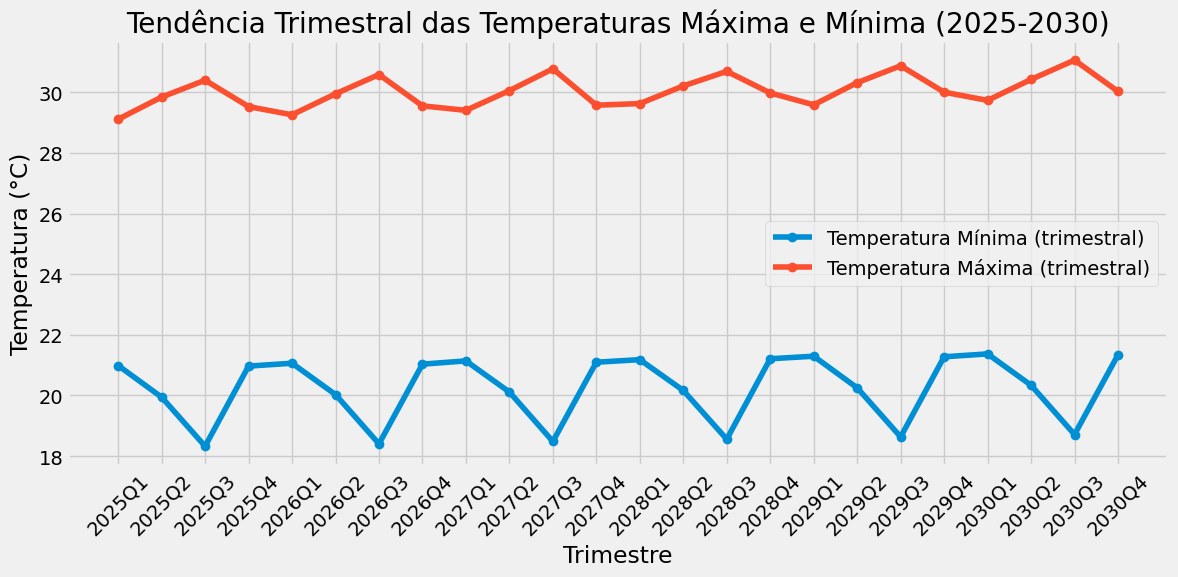

In [38]:
import matplotlib.pyplot as plt

# Filtrar e ordenar apenas trimestres a partir de 2025
minima_trimestre_2025 = previsao_trimestral_plot[previsao_trimestral_plot['quarter'] >= '2025Q1'].copy()
maxima_trimestre_2025 = forecast_5_years_quarterly[forecast_5_years_quarterly['quarter'] >= '2025Q1'].copy()

minima_trimestre_2025 = minima_trimestre_2025.sort_values('quarter')
maxima_trimestre_2025 = maxima_trimestre_2025.sort_values('quarter')

# Calcular a diferença entre o início e o fim da previsão trimestral para mínima
minima_inicio = minima_trimestre_2025['yhat'].iloc[0]
minima_fim = minima_trimestre_2025['yhat'].iloc[-1]
minima_delta = minima_fim - minima_inicio

# Calcular a diferença entre o início e o fim da previsão trimestral para máxima
maxima_inicio = maxima_trimestre_2025['yhat'].iloc[0]
maxima_fim = maxima_trimestre_2025['yhat'].iloc[-1]
maxima_delta = maxima_fim - maxima_inicio

# Exibir os resultados
print(f"Tendência Temperatura Mínima (2025Q1 a 2030Q4): {minima_inicio:.2f}°C → {minima_fim:.2f}°C | Δ = {minima_delta:.2f}°C")
print(f"Tendência Temperatura Máxima (2025Q1 a 2030Q4): {maxima_inicio:.2f}°C → {maxima_fim:.2f}°C | Δ = {maxima_delta:.2f}°C")

# Gráfico comparativo das tendências a partir de 2025
plt.figure(figsize=(12, 6))
plt.plot(minima_trimestre_2025['quarter'], minima_trimestre_2025['yhat'], label='Temperatura Mínima (trimestral)', marker='o')
plt.plot(maxima_trimestre_2025['quarter'], maxima_trimestre_2025['yhat'], label='Temperatura Máxima (trimestral)', marker='o')
plt.xlabel('Trimestre')
plt.ylabel('Temperatura (°C)')
plt.title('Tendência Trimestral das Temperaturas Máxima e Mínima (2025-2030)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/km/m1h59rm119n9h_rcz_wg84nc0000gn/T/ipykernel_7471/2405023380.py:4: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.

/var/folders/km/m1h59rm119n9h_rcz_wg84nc0000gn/T/ipykernel_7471/2405023380.py:5: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



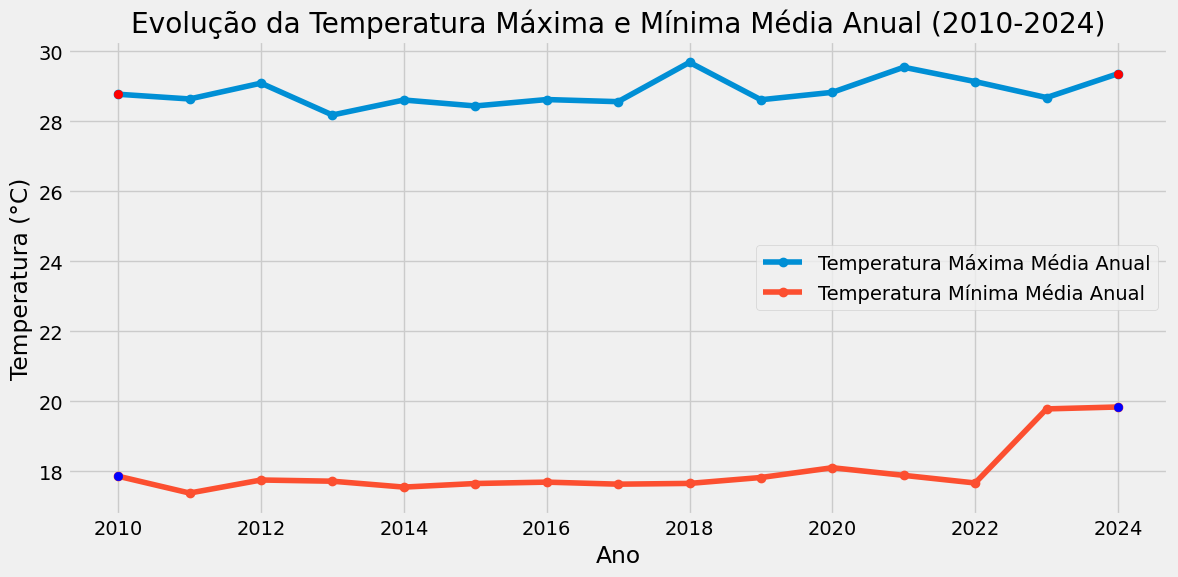

Variação da temperatura máxima média anual de 2010 a 2024: 28.78°C → 29.37°C | Δ = 0.59°C
Variação da temperatura mínima média anual de 2010 a 2024: 17.87°C → 19.84°C | Δ = 1.98°C
A temperatura máxima média anual aumentou no período.
A temperatura mínima média anual aumentou no período.


In [39]:
import matplotlib.pyplot as plt

# Médias anuais das temperaturas mínima e máxima
media_anual = train_df.resample('Y').mean()
media_anual_test = test_df.resample('Y').mean()
media_anual_total = pd.concat([media_anual, media_anual_test])

# Ajustar o índice para o ano
media_anual_total.index = media_anual_total.index.year

plt.figure(figsize=(12, 6))
plt.plot(media_anual_total.index, media_anual_total['temperatura_max'], marker='o', label='Temperatura Máxima Média Anual')
plt.plot(media_anual_total.index, media_anual_total['temperatura_min'], marker='o', label='Temperatura Mínima Média Anual')

# Destacar início e fim
plt.scatter(media_anual_total.index[0], media_anual_total['temperatura_max'].iloc[0], color='red', zorder=5)
plt.scatter(media_anual_total.index[-1], media_anual_total['temperatura_max'].iloc[-1], color='red', zorder=5)
plt.scatter(media_anual_total.index[0], media_anual_total['temperatura_min'].iloc[0], color='blue', zorder=5)
plt.scatter(media_anual_total.index[-1], media_anual_total['temperatura_min'].iloc[-1], color='blue', zorder=5)

plt.title('Evolução da Temperatura Máxima e Mínima Média Anual (2010-2024)')
plt.xlabel('Ano')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Cálculo da variação
delta_max = media_anual_total['temperatura_max'].iloc[-1] - media_anual_total['temperatura_max'].iloc[0]
delta_min = media_anual_total['temperatura_min'].iloc[-1] - media_anual_total['temperatura_min'].iloc[0]

print(f"Variação da temperatura máxima média anual de 2010 a 2024: {media_anual_total['temperatura_max'].iloc[0]:.2f}°C → {media_anual_total['temperatura_max'].iloc[-1]:.2f}°C | Δ = {delta_max:.2f}°C")
print(f"Variação da temperatura mínima média anual de 2010 a 2024: {media_anual_total['temperatura_min'].iloc[0]:.2f}°C → {media_anual_total['temperatura_min'].iloc[-1]:.2f}°C | Δ = {delta_min:.2f}°C")

if delta_max > 0:
    print("A temperatura máxima média anual aumentou no período.")
else:
    print("A temperatura máxima média anual reduziu no período.")

if delta_min > 0:
    print("A temperatura mínima média anual aumentou no período.")
else:
    print("A temperatura mínima média anual reduziu no período.")

# Resultados e Discussão

## Identificação da Sazonalidade

A análise dos gráficos de ACF e PACF revela uma forte tendência anual com defasagem de 12 meses, indicando uma sazonalidade clara. Isso sugere que a temperatura máxima de um determinado mês tende a se assemelhar à do mesmo mês do ano anterior. O PACF apresenta valores significativos nas defasagens 1 e 12, confirmando a existência de dependência tanto de curto quanto de longo prazo. A ACF mostra picos nos meses 12 e 24, reforçando o padrão sazonal anual. A sazonalidade é evidente tanto nas temperaturas máximas quanto nas mínimas, o que é compatível com o clima tropical da região do Uíge.

## Tendência de Longo Prazo

A decomposição STL da temperatura média máxima no Uíge apresenta três componentes principais: tendência, sazonalidade e resíduo. A série observada revela flutuações sazonais recorrentes ao longo do tempo. A tendência indica um aumento gradual da temperatura entre 2010 e 2015, possivelmente associado a alterações climáticas regionais ou eventos específicos. A sazonalidade é regular e se repete anualmente, com amplitude estável de aproximadamente 1,5°C. Os resíduos são pequenos, mas entre 2020 e 2022 houve desvios significativos, sugerindo eventos climáticos extremos.

Para a temperatura mínima, os dados mostram:

* Linha preta: valores observados, com clara variabilidade sazonal;
* Linha azul (tendência): leve declínio ao longo dos anos, indicando uma possível queda nas temperaturas mínimas;
* Linha verde (sazonalidade): padrões sazonais bem definidos;
* Linha vermelha (resíduo): variações aleatórias, sem padrão claro, sugerindo que o modelo se ajusta bem aos dados.

Essas observações podem estar associadas a **mudanças climáticas globais, desmatamento local** e **urbanização crescente no Uíge**, reforçando a importância de estratégias de monitoramento e adaptação ambiental.

## Ciclos Relevantes

Além da sazonalidade de 12 meses, foram identificados ciclos climáticos moderados de 3 a 5 anos, como observado na tendência entre 2012 e 2018. Esses ciclos podem estar ligados a fenômenos como El Niño e La Niña, que influenciam o clima na África Central.

As temperaturas mínimas apresentam variações entre 14°C e 18°C. A tendência mostra declínios específicos ao longo do tempo, enquanto a sazonalidade é consistente. Embora esses ciclos plurianuais sejam menos regulares, sua identificação é fundamental para prever extremos de temperatura.

## Anomalias Climáticas

Foram identificadas anomalias de temperatura nos últimos anos:

* Em julho de 2021, houve um pico de 34°C;
* Em julho de 2022, a temperatura foi de 33°C;
* Em julho de 2023, registrou-se uma queda significativa (\~4°C), com as temperaturas mais baixas dos últimos quatro anos, tanto para máximas quanto para mínimas;
* Em julho de 2024, as temperaturas voltaram a subir, alcançando novamente 33°C.

A previsão feita com o modelo Prophet indica uma temperatura máxima de 30,7°C para julho de 2025. Essas anomalias indicam possíveis falhas no regime de chuvas, eventos extremos ou mudanças no uso do solo. A análise dos resíduos da decomposição corrobora essas irregularidades.

## Variação Climática

Observa-se uma elevação das médias anuais entre 2010 e 2024:

* Temperatura máxima média: de 28,78°C para 29,37°C (Δ = +0,59°C);
* Temperatura mínima média: de 17,87°C para 19,84°C (Δ = +1,98°C).

Esses dados confirmam um aumento significativo das temperaturas, particularmente das mínimas, o que pode ter implicações importantes para a saúde pública e agricultura.

## Previsão

As previsões apontam:

* A temperatura máxima apresentará aumento entre o 1º trimestre de 2025 e o 4º trimestre de 2030: de 29,11°C para 30,02°C (Δ = +0,92°C);
* A temperatura mínima aumentará de 20,99°C para 21,34°C no mesmo período (Δ = +0,35°C).

Prevê-se que os picos de temperatura máxima ocorram no 3º trimestre dos anos entre 2025 e 2029, e no 4º trimestre de 2030. Já o ponto mínimo da temperatura mínima será registrado no mês de junho, com previsão de 12°C.

## Aplicações Práticas e Impactos

As variações e anomalias climáticas observadas têm implicações diretas em diversos setores:

* **Agricultura**: mudanças no calendário agrícola e riscos maiores de secas ou geadas inesperadas;
* **Saúde pública**: aumento de doenças relacionadas ao calor e à umidade;
* **Planejamento urbano**: necessidade de adaptar construções e infraestrutura para extremos climáticos;
* **Gestão ambiental**: reforça a importância de políticas públicas de reflorestamento, controle da urbanização e uso sustentável do solo.

Portanto, compreender essas dinâmicas climáticas é essencial para desenvolver **estratégias locais de mitigação e adaptação**, especialmente em regiões vulneráveis como o Uíge.

